In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
import pandas as pd
from scipy.stats import ttest_ind
import scipy.stats as stats
import numpy as np
warnings.filterwarnings('ignore')


In [3]:
conn=sqlite3.connect('inventory.db')

df=pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actualprice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


## Exploratory Data Analysis
- Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be
included in the final analysis.
- In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
Actualprice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05


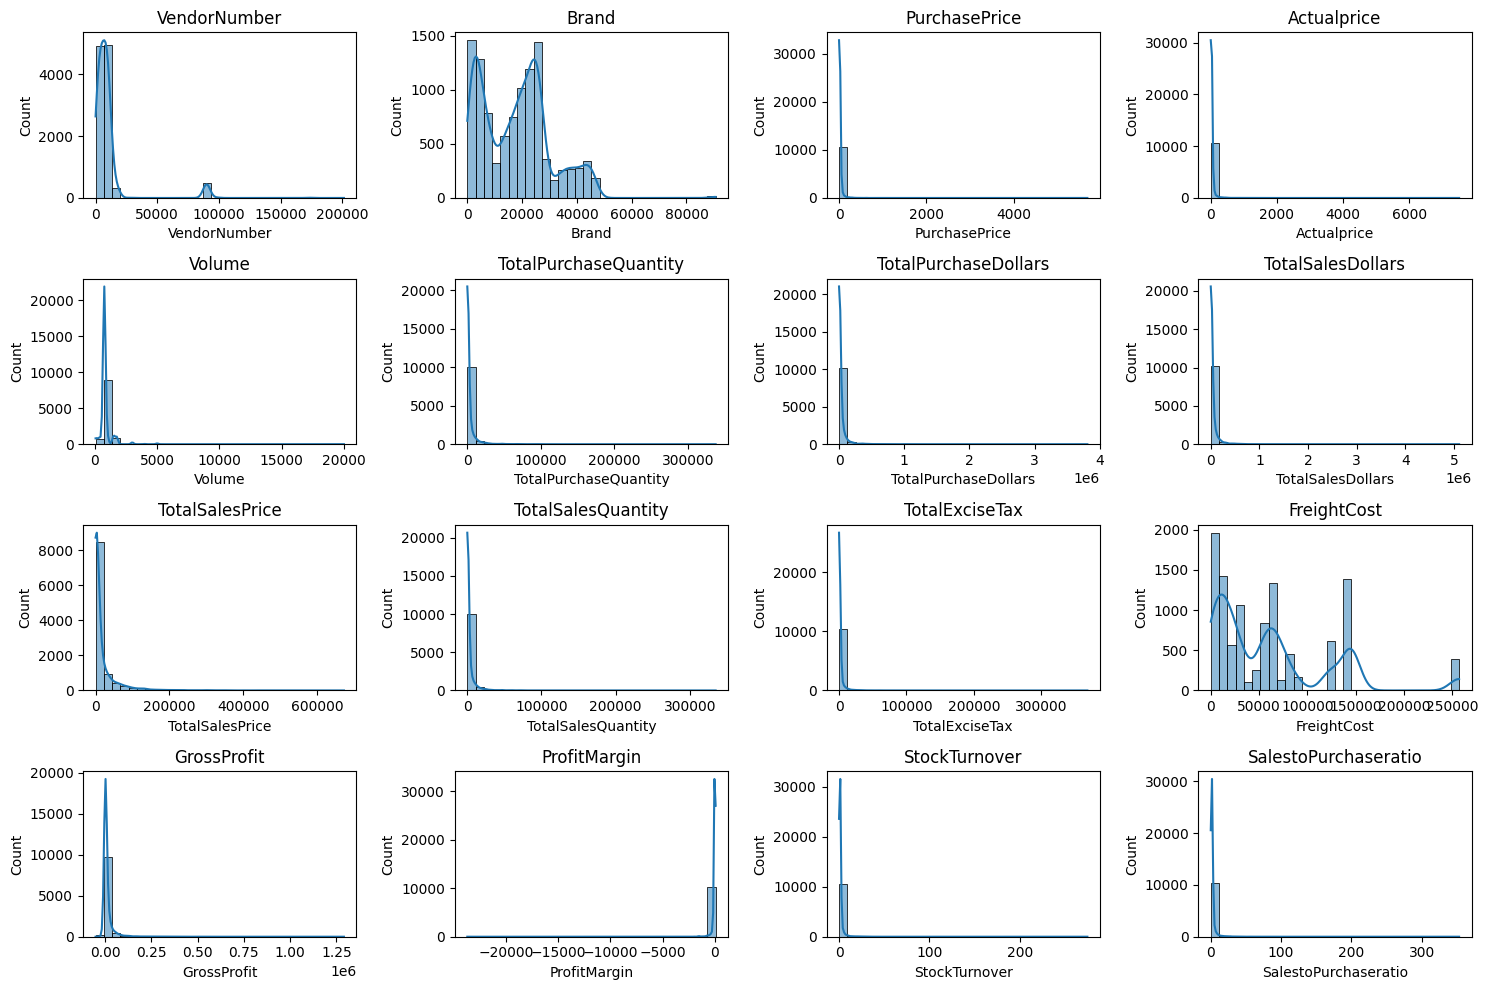

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)   # Adjust grid layout as needed 
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

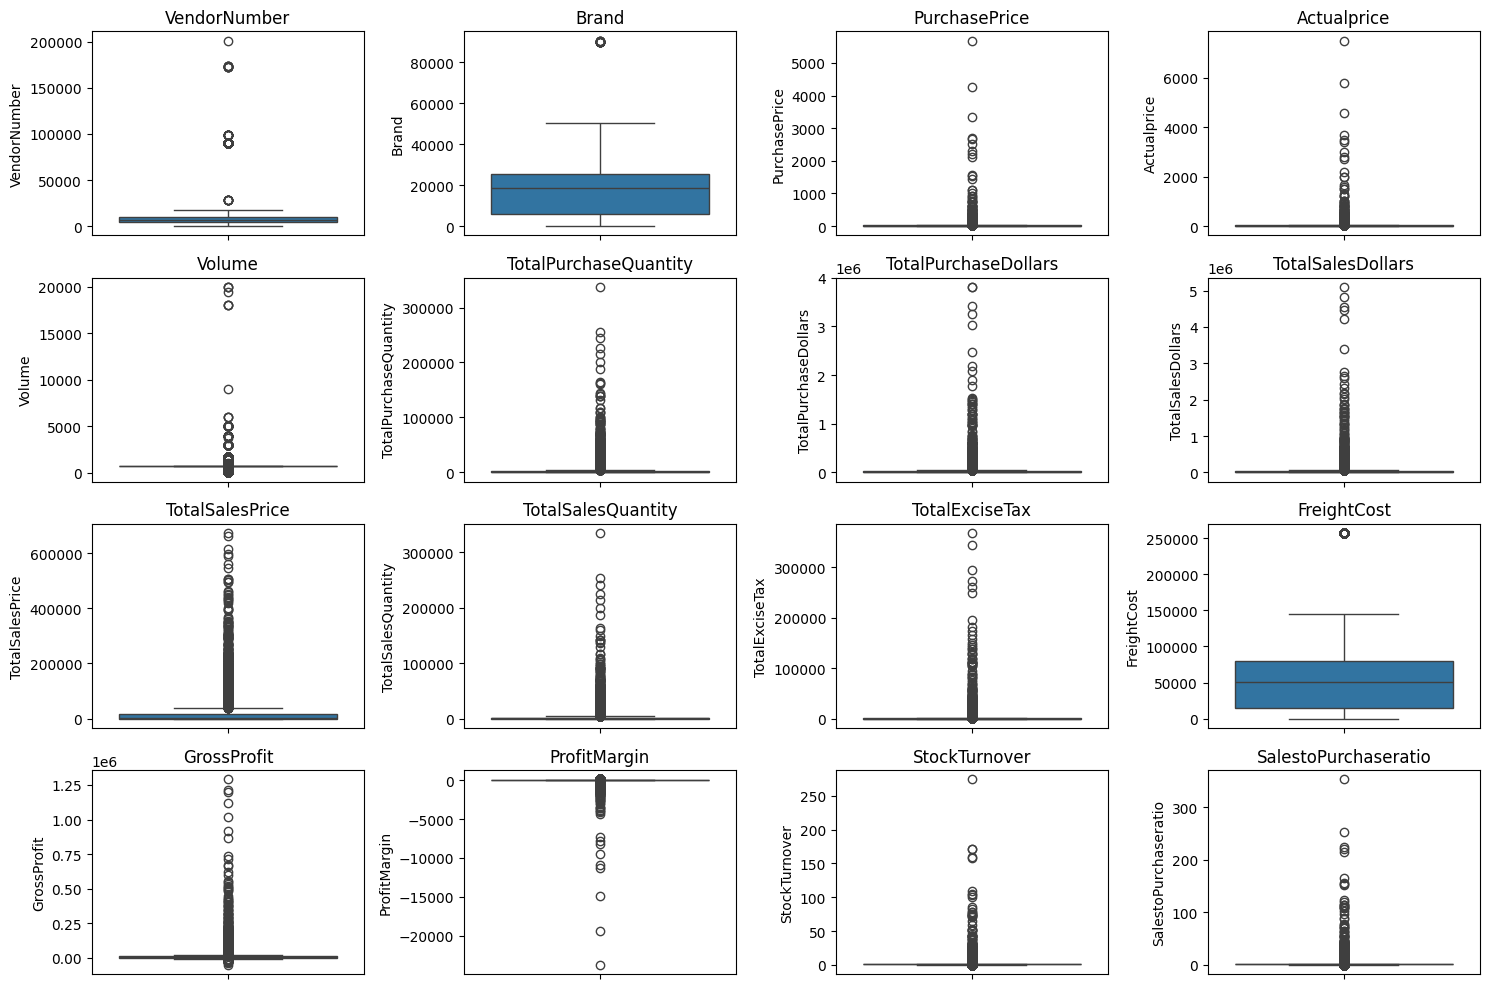

In [6]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols) :
    plt.subplot(4, 4, i+1)  
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:
#### Negative & Zero Values:
- Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price...
- Profit Margin: Has a minimum of -o, which suggests cases where revenue is zero or even lower than costs.
- Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.
#### Outliers Indicated by High Standard Deviations:
- Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.
- Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.
- Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [7]:
# filter data by removing inconsistencies
df=pd.read_sql_query("SELECT * FROM vendor_sales_summary WHERE GrossProfit>0 AND ProfitMargin>0 AND TotalSalesQuantity>=0", conn)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actualprice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseratio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,15.95,10.96,5.0,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,65.66,1.47,134.0,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,1.98,0.99,2.0,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,143.28,77.61,72.0,15.12,257032.07,141.81,98.974037,72.000000,97.469388


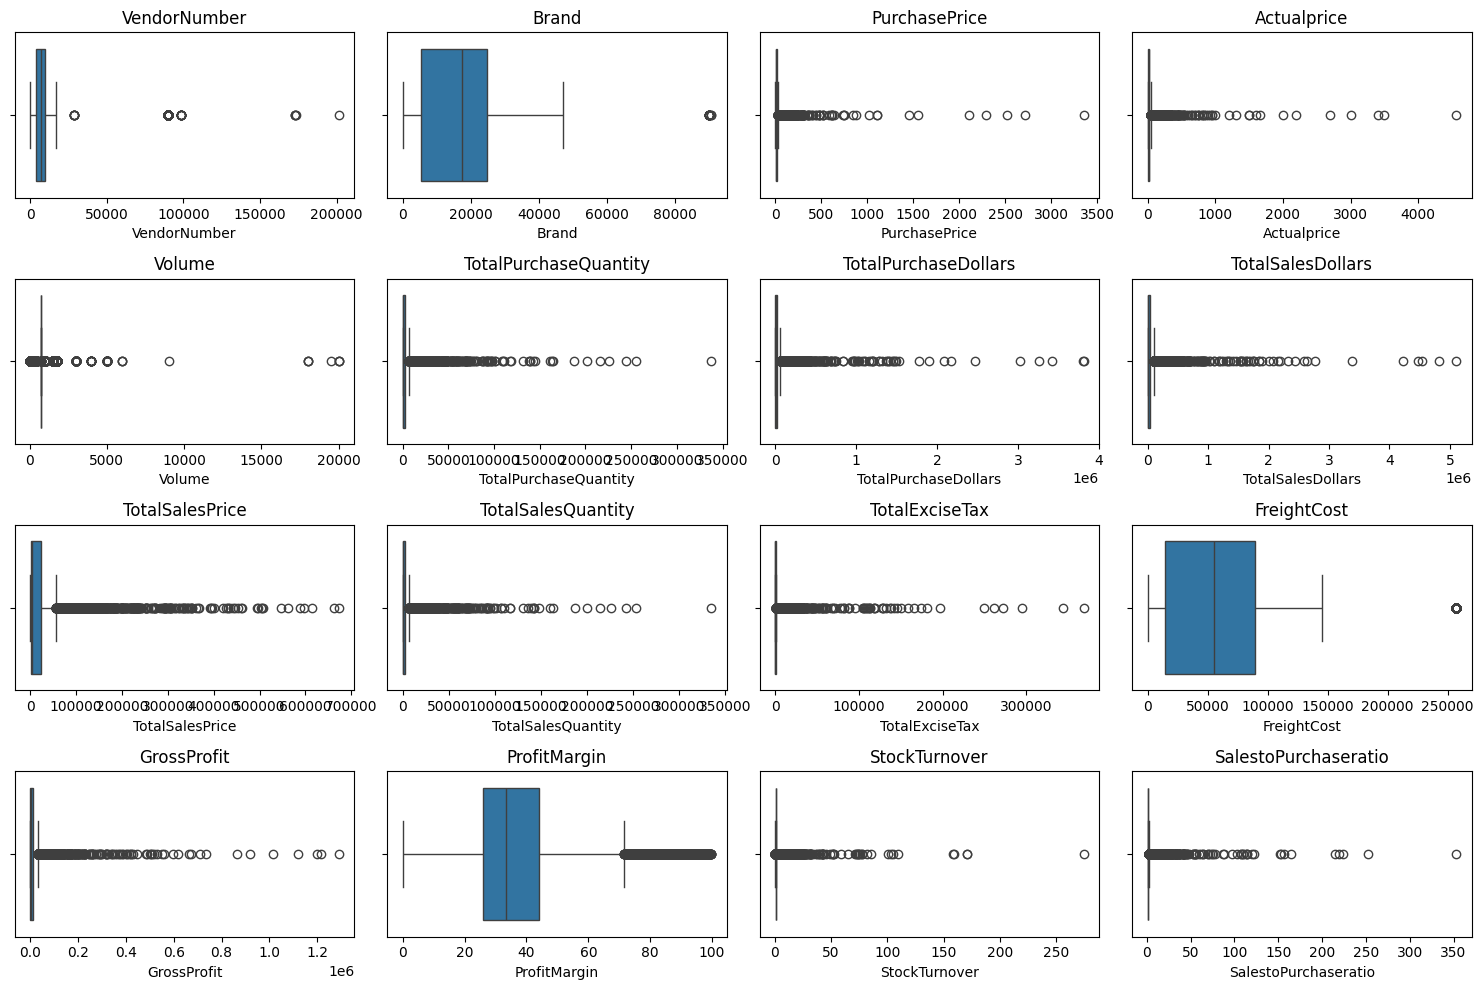

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)  
    sns.boxplot(x=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [10]:
# count plot for categorical columns

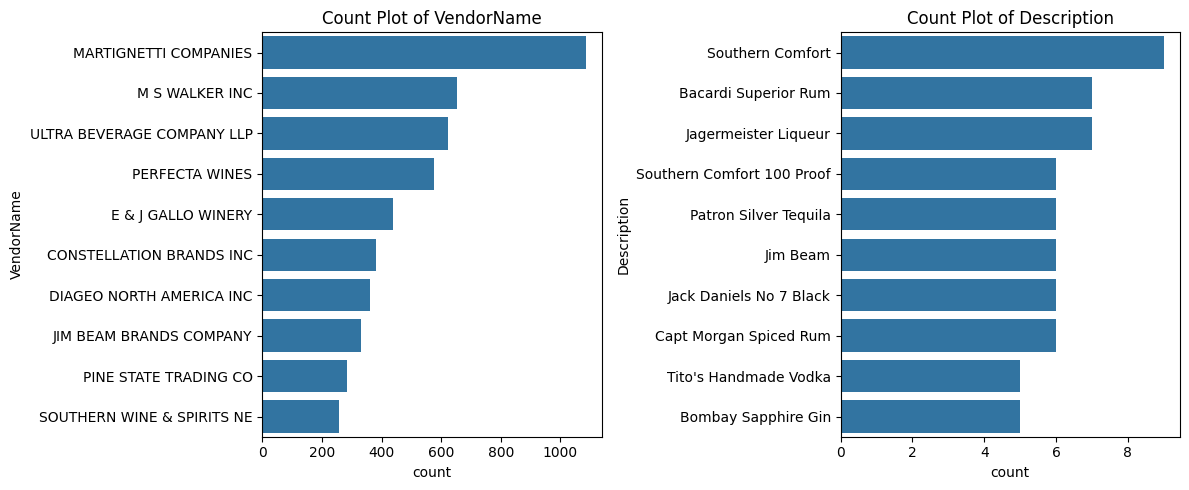

In [11]:
categorical_cols=['VendorName',"Description"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols) :
    plt.subplot(1, 2, i+1)   # Adjust grid layout as needed 
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

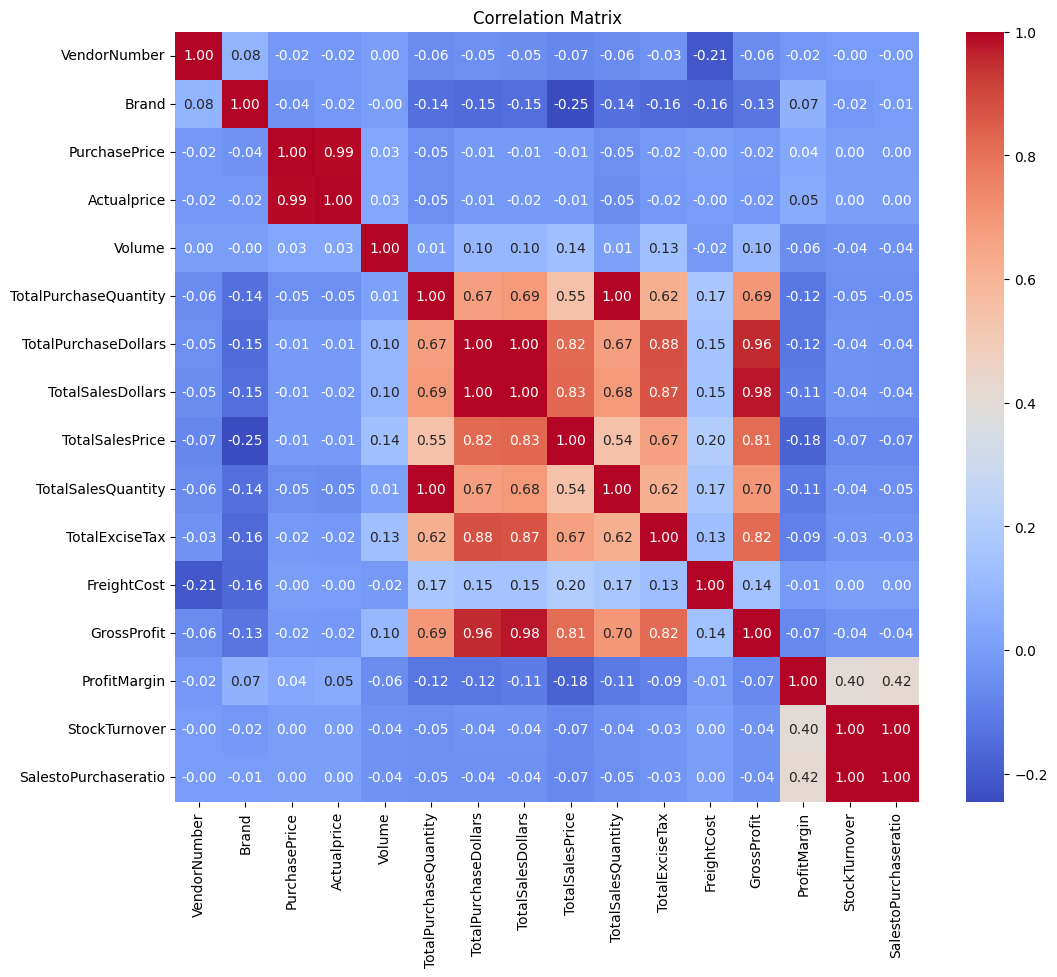

In [12]:
import sqlite3
if 'df' not in globals():
    conn = sqlite3.connect('inventory.db')
    df = pd.read_sql_query("SELECT * FROM vendor_sales_summary WHERE GrossProfit>0 AND ProfitMargin>0 AND TotalSalesQuantity>=0", conn)
    conn.close()

numeric_df = df.select_dtypes(include=np.number)
if numeric_df.shape[1] == 0:
    print('No numeric columns available for correlation.')
else:
    correlation_matrix = numeric_df.corr()
    plt.figure(figsize=(12,10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

# Correlation Insights
- PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profic
- Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.
- Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.
- StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

# Data Analysis
- Identify brands that needs promotional or price adjustments which exhibit lower sales performance but higher profit margins.

In [13]:
brand_performance=df.groupby('Description').agg({'TotalSalesQuantity':'sum','ProfitMargin':'mean'}).reset_index()

In [14]:
low_sales_threshold = brand_performance['TotalSalesQuantity'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [15]:
low_sales_threshold

26.0

In [16]:
high_margin_threshold

64.97017552750113

In [17]:
# filter brands with low sales and high profit margin
target_brands = brand_performance[
    (brand_performance['TotalSalesQuantity'] <= low_sales_threshold) & (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brand with low sales but high profit margin:")
display(target_brands.sort_values('TotalSalesQuantity'))

Brand with low sales but high profit margin:


,Description,TotalSalesQuantity,ProfitMargin
6199,Santa Rita Organic Svgn Bl,1.0,66.466466
1932,Circadia Cab Svgn Napa Vly,1.0,68.035738
1689,Ch Pagodes de Cos 10 Brdx,1.0,67.536754
3866,Jean Luc Colombo Ruchets 07,2.0,65.514439
1546,Ch Fonroque St Emilion 10,2.0,67.532218
...,...,...,...
1186,Camus Extra Elegance,26.0,83.031854
1635,Ch Le Petite Mouton 12 Pauil,26.0,84.193701
4370,Legacy Red Alexander Valley,26.0,76.613875
5653,Pommerey Brut Rose Champagne,26.0,79.755600


In [18]:
# Filter brands by low total sales quantity (fix: TotalSalesDollars not present)
brand_performance = brand_performance[brand_performance['TotalSalesQuantity'] < 10000]

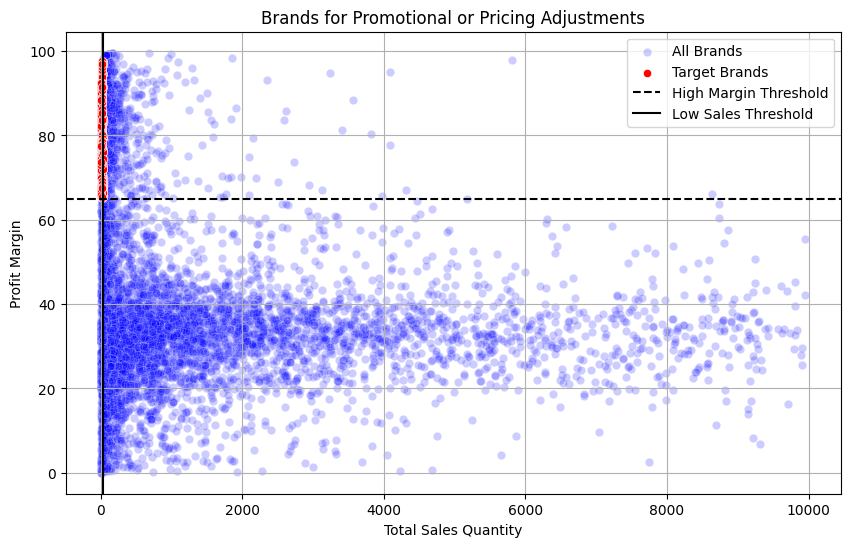

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesQuantity', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesQuantity', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label='High Margin Threshold')
plt.axvline(low_sales_threshold, linestyle='-', color='black', label='Low Sales Threshold')

plt.xlabel("Total Sales Quantity")
plt.ylabel("Profit Margin")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

#### Which vendors and brands demonstrate the highest sales performance?

In [20]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [21]:
#top vendorrs and brands by sales performance

top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [22]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [23]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

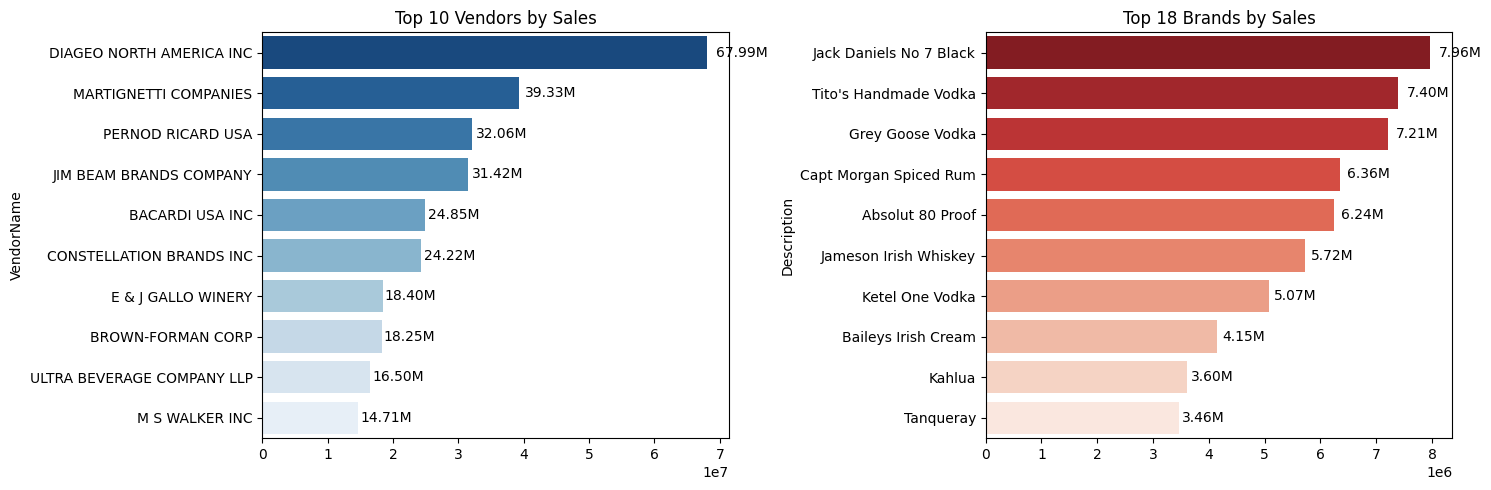

In [24]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors 
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors. values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha="left", va="center", fontsize=10, color="black")

# Plot for top brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands. values, palette="Reds_r")
plt.title("Top 18 Brands by Sales") 
for bar in ax2.patches:
    ax2.text (bar.get_width() + (bar.get_width() * 0.02),
    bar.get_y() + bar.get_height() / 2,
    format_dollars(bar.get_width()),
    ha='left', va='center', fontsize=10, color= 'black')
plt. tight_layout()
plt.show()

#### Which vendors contribute the most to total purchase dollars?

In [25]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum',
})

In [26]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()

In [27]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [28]:
# display top 10 vendors
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
VendorName,,,,
DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08
PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08
JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08
BACARDI USA INC,17.43M,7.42M,24.85M,0.06
CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05
BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04
E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04
ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04


In [29]:
top_vendors['PurchaseContribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
VendorName,,,,
DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.24
PERNOD RICARD USA,23.85M,8.21M,32.06M,0.32
JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.40
BACARDI USA INC,17.43M,7.42M,24.85M,0.46
CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.51
BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.55
E & J GALLO WINERY,12.07M,6.33M,18.40M,0.59
ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.63


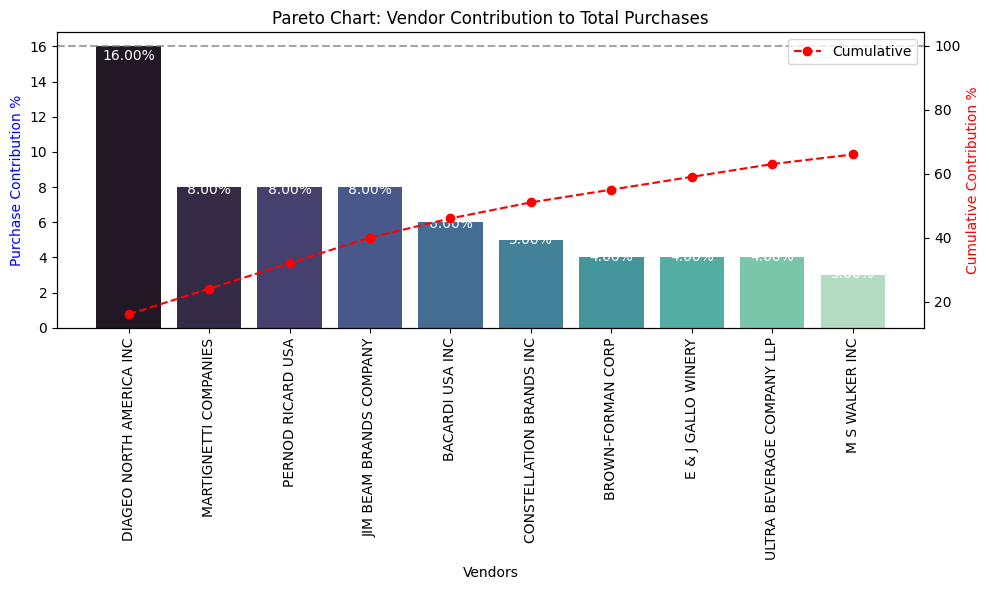

In [30]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Use the original vendor_performance to get per-vendor and cumulative contributions
per = vendor_performance.copy().reset_index().head(10)
# Ensure PurchaseContribution% is a percentage (multiply by 100 if it's fractional)
if per['PurchaseContribution%'].max() <= 1:
    per['PurchaseContribution%'] = per['PurchaseContribution%'] * 100
per['Cumulative_Contribution%'] = per['PurchaseContribution%'].cumsum()

# Bar plot for Purchase Contributions
sns.barplot(x=per['VendorName'], y=per['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(per['PurchaseContribution%']):
    ax1.text(i, value - (value * 0.05), f"{value:.2f}%", ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contributions
ax2 = ax1.twinx()
ax2.plot(per['VendorName'], per['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative')

ax1.set_xticklabels(per['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color="blue")
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel("Vendors")
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

#### How much of total procurement is dependent on the top vendors?

In [32]:
top_vendors = vendor_performance.head(10).copy()
print(
    f"Total purchase contribution of the top 10 vendors is "
    f"{round(top_vendors['PurchaseContribution%'].sum() * 100, 2)}%"
)

Total purchase contribution of the top 10 vendors is 66.0%


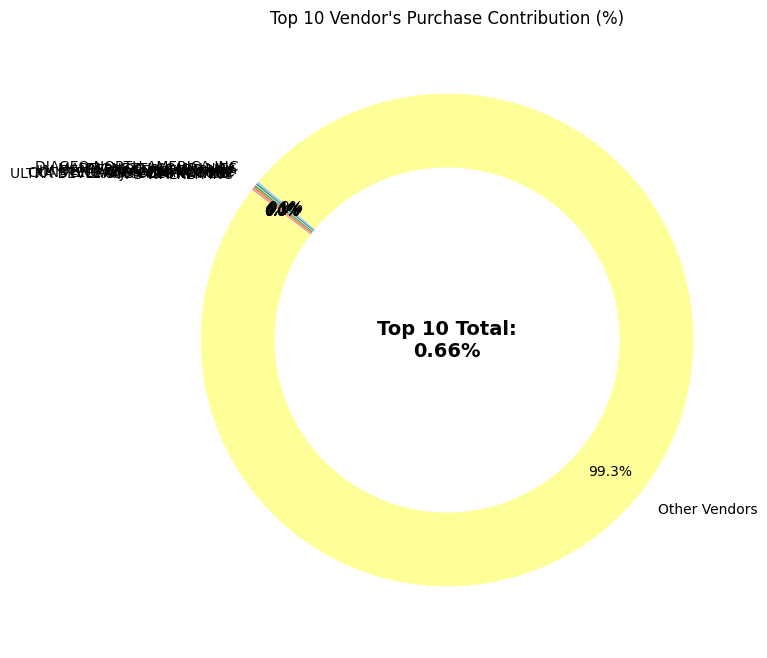

In [35]:
top_vendors = vendor_performance.head(10).copy()
vendors = list(top_vendors.index)
purchase_contributions = list(top_vendors["PurchaseContribution%"].values)
total_contribution = sum(purchase_contributions)
remaining_contribution =  100 - total_contribution

#append other vendors
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

#donut chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

centre_circle = plt.Circle((0, 0), 0.70, fc="white")
fig.gca().add_artist(centre_circle)

plt.text(
    0,
    0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight="bold",
    ha="center",
    va="center"
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

#### Does purchasing in bulk reduce the unit price, and what is the optiomal purchase volume for cost saving?

In [37]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalSalesQuantity']

df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Actualprice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseratio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,5101919.51,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647,26.830542
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,4819073.49,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830,23.738611
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,4538120.60,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594,18.266024
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,4475972.88,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493,16.272468
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,4223107.62,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897,22.255967
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,15.95,10.96,5.0,0.55,27100.41,13.31,83.448276,2.500000,6.041667,0.528000
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,65.66,1.47,134.0,7.04,50293.62,63.32,96.436186,22.333333,28.059829,0.017463
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,1.98,0.99,2.0,0.10,14069.87,0.50,25.252525,1.000000,1.337838,0.740000
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,143.28,77.61,72.0,15.12,257032.07,141.81,98.974037,72.000000,97.469388,0.020417


In [ ]:
df['OrderSize'] = pd.qcut(df['TotalSalesQuantity'] , q=3, labels=['small', 'medium', 'large'])


0        large
1        large
2        large
3        large
4        large
         ...  
8559     small
8560    medium
8561     small
8562     small
8563     small
Name: OrderSize, Length: 8564, dtype: category
Categories (3, object): ['small' < 'medium' < 'large']

In [40]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
small,30.099112
medium,14.263308
large,10.821893


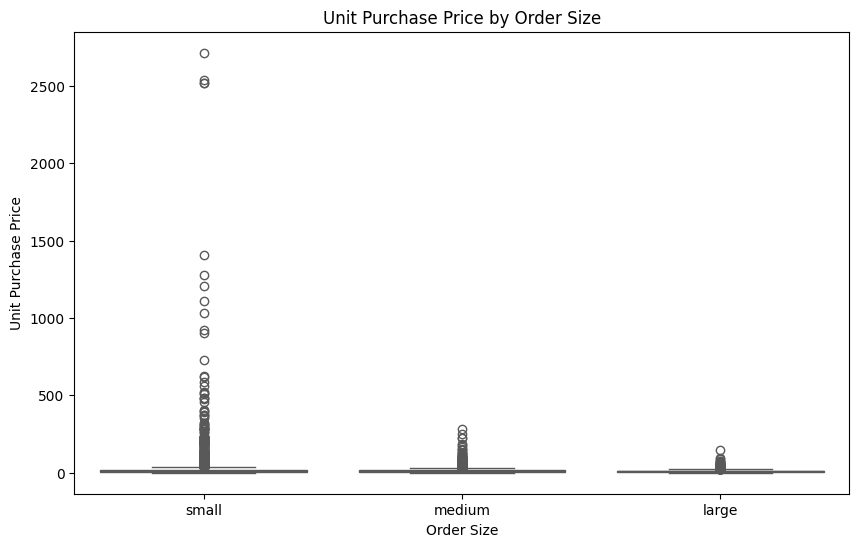

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='OrderSize',   y='UnitPurchasePrice', data=df, palette="Set2")
plt.title("Unit Purchase Price by Order Size")
plt.xlabel("Order Size")
plt.ylabel("Unit Purchase Price")
plt.show()

- vendors buying in bulk gets the lowest unit price, meaning higher margins if they can manage inventory efficiently.
- the price difference between small and large orders is substainal
- this suggest that bulk price stratigies successfully encourage vendors to purchase in large volumes, leading in large volume,leadung in higher overall sales despite lower per-unit revenue

#### Which vendor has lowest inventory turnover, indicatomg excess stock and slow-moving products?

In [42]:
df[df['StockTurnover']< 1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


#### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [43]:
df["UnsoldInventoryValue"]=(df["TotalPurchaseQuantity"] - df['TotalSalesQuantity']) * df['PurchasePrice']
print('Total Unsold Inventory Value:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Inventory Value: 2.71M


In [45]:
# aggregate captial locker per vendor
inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

#sort vendors with the highest locker capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values('UnsoldInventoryValue', ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


#### waht is the 95% confidence for profit margins of top-performing and low-performing vendors.

In [46]:
top_threshold=df['UnsoldInventoryValue'].quantile(0.75)
low_threshold=df['UnsoldInventoryValue'].quantile(0.25)

In [51]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [54]:
low_vendors

Series([], Name: ProfitMargin, dtype: float64)

In [56]:
def confidence_interval(data, confidence=0.95) :
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

Top vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


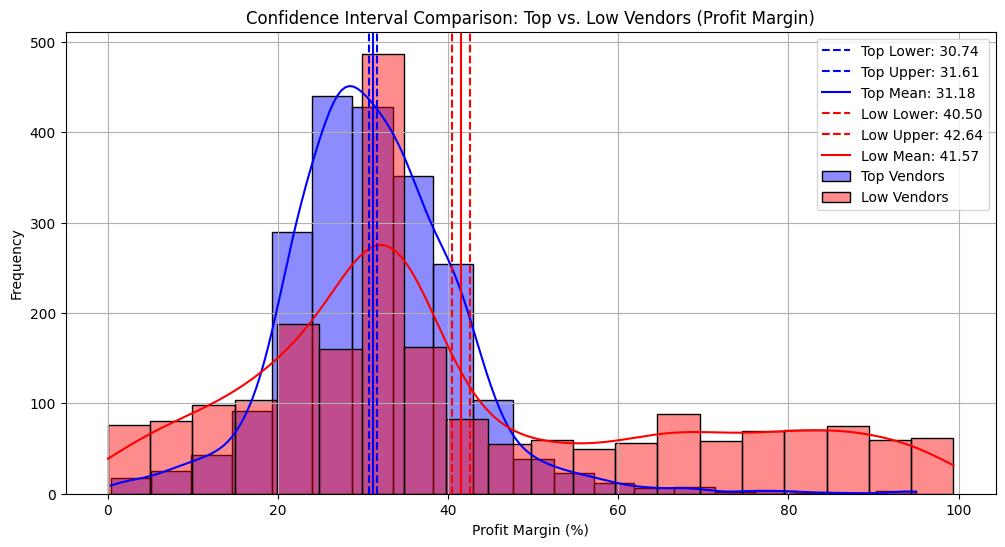

In [59]:
# Recompute thresholds from TotalSalesDollars so both groups are populated
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Plot both distributions clearly
sns.histplot(top_vendors, bins=20, kde=True, color="blue", alpha=0.45, edgecolor="black",
             label="Top Vendors")
sns.histplot(low_vendors, bins=20, kde=True, color="red", alpha=0.45, edgecolor="black",
             label="Low Vendors")

plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

- The confidence interval for low-performing vendors (40.48% to 42.42%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### Is there a significant difference in profit margins between top-performing and low-performing vendbrs? 
Hypothesis:

Ho (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [61]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H0: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H0: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject H0: There is a significant difference in profit margins between top and low-performing vendors.
